In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
sales = pd.read_csv("sales_data.csv")
churn = pd.read_csv("customer_churn.csv")

print("Sales Data:\n", sales.head())
print("\nChurn Data:\n", churn.head())

Sales Data:
          Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680

Churn Data:
   CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No     

In [6]:
# Clean column names
sales.columns = sales.columns.str.strip()

# Show columns
print("Columns:", sales.columns)

# Try to detect correct sales column
sales_col = None
for col in sales.columns:
    if 'sale' in col.lower():
        sales_col = col

print("Using column:", sales_col)

# Descriptive statistics
print("\nDescriptive Statistics:\n")
print(sales.describe())

mean_sales = sales[sales_col].mean()
median_sales = sales[sales_col].median()
mode_sales = sales[sales_col].mode()[0]
std_sales = sales[sales_col].std()

print("\nMean:", mean_sales)
print("Median:", median_sales)
print("Mode:", mode_sales)
print("Standard Deviation:", std_sales)

Columns: Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')
Using column: Total_Sales

Descriptive Statistics:

         Quantity         Price    Total_Sales
count  100.000000    100.000000     100.000000
mean     4.780000  25808.510000  123650.480000
std      2.588163  13917.630242  100161.085275
min      1.000000   1308.000000    6540.000000
25%      2.750000  14965.250000   39517.500000
50%      5.000000  24192.000000   97955.500000
75%      7.000000  38682.250000  175792.500000
max      9.000000  49930.000000  373932.000000

Mean: 123650.48
Median: 97955.5
Mode: 6540
Standard Deviation: 100161.08527499213


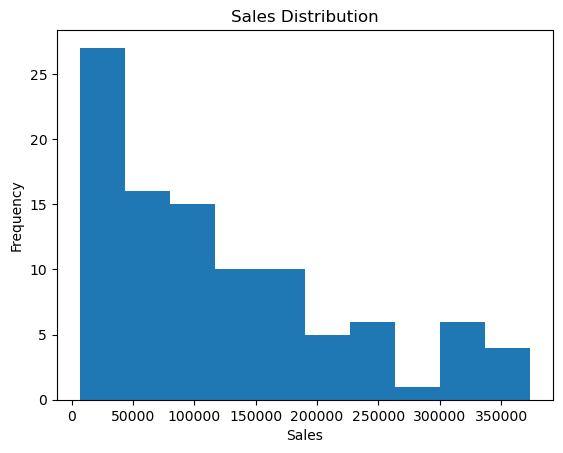

In [7]:
plt.figure()
plt.hist(sales[sales_col])
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

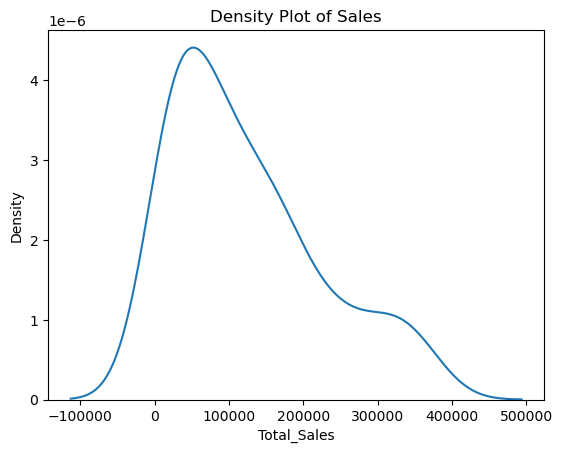

In [8]:
plt.figure()
sns.kdeplot(sales[sales_col])
plt.title("Density Plot of Sales")
plt.show()

Correlation Matrix:
              Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


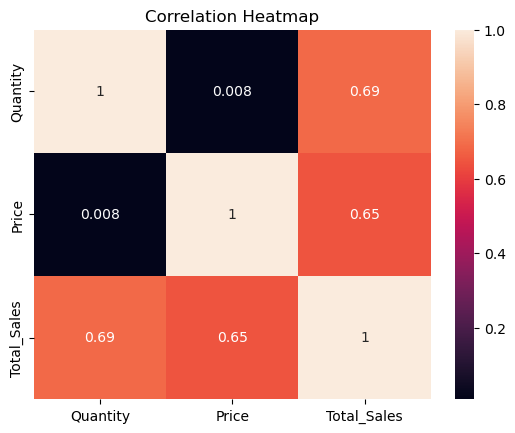

In [9]:
# Clean column names again (safe practice)
sales.columns = sales.columns.str.strip()

correlation = sales.corr(numeric_only=True)

print("Correlation Matrix:\n", correlation)

plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [10]:
# Check column names first
print(sales.columns)

# Replace 'Region' if your column name is different
region_col = None
for col in sales.columns:
    if 'region' in col.lower():
        region_col = col

print("Using Region Column:", region_col)

group1 = sales[sales[region_col] == sales[region_col].unique()[0]][sales_col]
group2 = sales[sales[region_col] == sales[region_col].unique()[1]][sales_col]

t_stat, p_val = stats.ttest_ind(group1, group2)

print("T-Test Result:")
print("T-Statistic:", t_stat)
print("P-Value:", p_val)

Index(['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region',
       'Total_Sales'],
      dtype='object')
Using Region Column: Region
T-Test Result:
T-Statistic: -0.35710677600784724
P-Value: 0.7226811638407535


In [12]:
# Find numeric columns
numeric_cols = sales.select_dtypes(include=np.number).columns

print("Numeric Columns:", numeric_cols)

# Remove sales column from list
other_cols = [col for col in numeric_cols if col != sales_col]

# Pick first numeric column as marketing proxy
marketing_col = other_cols[0]

print("Using Column for Comparison:", marketing_col)

corr, p_value = stats.pearsonr(sales[marketing_col], sales[sales_col])

print("Correlation:", corr)
print("P-Value:", p_value)

Numeric Columns: Index(['Quantity', 'Price', 'Total_Sales'], dtype='object')
Using Column for Comparison: Quantity
Correlation: 0.6881074758580694
P-Value: 2.580513799627829e-15


In [13]:
# Clean churn columns
churn.columns = churn.columns.str.strip()

print(churn.columns)

# Detect columns
churn_col = None
charge_col = None

for col in churn.columns:
    if 'churn' in col.lower():
        churn_col = col
    if 'charge' in col.lower():
        charge_col = col

print("Churn Column:", churn_col)
print("Charges Column:", charge_col)

churn_yes = churn[churn[churn_col] == 1][charge_col]
churn_no = churn[churn[churn_col] == 0][charge_col]

t_stat2, p_val2 = stats.ttest_ind(churn_yes, churn_no)

print("Churn Test:")
print("T-Statistic:", t_stat2)
print("P-Value:", p_val2)

Index(['CustomerID', 'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract',
       'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen', 'Churn'],
      dtype='object')
Churn Column: Churn
Charges Column: TotalCharges
Churn Test:
T-Statistic: 0.09483950239329238
P-Value: 0.9244804573599807


In [14]:
confidence = 0.95
n = len(sales[sales_col])
mean = np.mean(sales[sales_col])
std_err = stats.sem(sales[sales_col])

margin = std_err * stats.t.ppf((1 + confidence) / 2, n-1)

print("Confidence Interval:")
print(mean - margin, "to", mean + margin)

Confidence Interval:
103776.34767158539 to 143524.6123284146


In [16]:
# Get numeric columns
numeric_cols = sales.select_dtypes(include=np.number).columns.tolist()

print("Numeric Columns:", numeric_cols)

# Remove sales column
numeric_cols.remove(sales_col)

# Use first available column as independent variable
marketing_col = numeric_cols[0]

print("Using column for regression:", marketing_col)

X = sales[[marketing_col]]
y = sales[sales_col]

model = LinearRegression()
model.fit(X, y)

r_squared = model.score(X, y)

print("Regression Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R-squared:", r_squared)

Numeric Columns: ['Quantity', 'Price', 'Total_Sales']
Using column for regression: Quantity
Regression Coefficient: 26629.5442427167
Intercept: -3638.7414801858395
R-squared: 0.47349189833176386


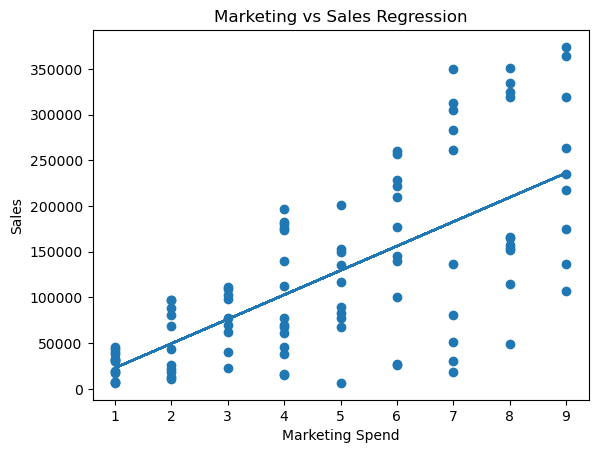

In [17]:
plt.figure()
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.title("Marketing vs Sales Regression")
plt.xlabel("Marketing Spend")
plt.ylabel("Sales")
plt.show()